# 01 Regional and Geologic Context

Developed by: Lilly Jones, PhD, Daear Consulting LLC                                                                               
Developed for: Oglala Lakota College                                                                                            
Funding: This material was developed as part of a project funded by the USDA National Institute of Food and Agriculture (NIFA).                       
Project role: Daear Consulting LLC developed the geospatial code, workflows, documentation, and instructional materials under contract to Oglala Lakota College.                                                                           
License: Apache License 2.0 (code; review of other materials is pending)

## Data Sovereignty and Governance (draft under review)
This repository contains workflows developed for use in support of Oglala Lakota College and Oglala Sioux Tribe–related research, education, and data activities. Public availability of code or documentation does not imply that Tribal data, knowledge, or derived information are open or unrestricted. Use of Tribal data and knowledge remains subject to applicable Tribal governance, permissions, protocols, and data sovereignty requirements.

## Setting the Stage

the Pine Ridge Reservation lie in the physiographic transition zone
between the Missouri Plateau (part of the Great Plains) and the Black Hills
uplift. This position determines everything about the
geology, soils, water, and landscape of these lands.

The reservations sit on the western flank of the Williston Basin structural
province. Regional dip carries strata gently eastward off the Black Hills
uplift, producing a predictable sequence from older, deeper formations in the
west to younger, shallower units in the east. The Pierre Shale, one of the
most extensive units in North America, forms the dominant near-surface
geology across most of the Pine Ridge Reservation.

This notebook establishes the spatial and stratigraphic framework that all
subsequent notebooks build on. It is the entry point for geologists unfamiliar
with the region and for Tribal scientists and community members who want to
understand their lands in a geologic context.

In [1]:
# Imports
import sys
from pathlib import Path
REPO_ROOT = next(
    (parent for parent in (Path.cwd(), *Path.cwd().parents)
     if (parent/"src").is_dir() and (parent/"config"/"config.yaml").is_file()),
    None,
)
if REPO_ROOT is None:
    raise RuntimeError("Open this notebook from the tribal-soils-geology repository or a subdirectory.")
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
import warnings
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import contextily as ctx
import yaml
from shapely.geometry import box
from src.constants import (
    CRS_GEOGRAPHIC, CRS_PROJECTED, CRS_WEB,
    REPO_ROOT as _REPO_ROOT, OUTPUTS_DIR, FIGURES_DIR,
    PINE_RIDGE_BBOX, STUDY_BBOX,WSD_STRATIGRAPHY,
    WSD_KEY_UNITS,
    WSD_3D_MODEL,
)

from src.loaders import (
    load_tribal_boundaries, load_state_geology, load_nhd_flowlines
)
from src.sovereignty import print_data_acknowledgment, generate_citations, attach_provenance
warnings.filterwarnings("ignore", category=FutureWarning)
%matplotlib inline
with open(_REPO_ROOT/"config"/"config.yaml") as f:
    CONFIG = yaml.safe_load(f)
TEAL = "#007A6E"; TEAL_LT = "#E0F4F2"; GRAY = "#566573"
def despine(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
primary = load_tribal_boundaries(["Pine Ridge"])
print(f"Environment ready. Primary nations: {len(primary)}")

Environment ready. Primary nations: 1


In [2]:
# Print data acknowledgement at the top of every notebook
print_data_acknowledgment(source_keys=["census_aiannh", "usgs_3d_model"])

TRIBAL SOILS AND GEOLOGY DATA GOVERNANCE ACKNOWLEDGMENT

This analysis uses data that describes the lands and subsurface
resources of the Oglala Sioux Tribe and the Oglala Lakota people.
peoples. This data is governed by the following frameworks:

OCAP®  : Tribal Nations have the right to Ownership, Control,
         Access, and Possession of data about their lands,
         including subsurface geological and soil data.
         Reference: https://fnigc.ca/ocap-training/

CARE   : Data use must deliver Collective Benefit to Indigenous
         peoples, respect their Authority to Control, uphold
         Responsibility to communities, and center Ethics.
         Reference: https://www.gida-global.org/care

FAIR   : Data is Findable, Accessible, Interoperable, Reusable.
         FAIR governs technical standards; CARE and OCAP® govern
         the ethical obligations FAIR alone does not address.
         Reference: https://www.go-fair.org/fair-principles/

IEEE 2890-2025 : Recommended Pr

## Tribal Boundaries and Study Area

In [3]:
# Load the Pine Ridge Reservation boundary
primary = load_tribal_boundaries(["Pine Ridge"])

print(f"Primary reservation boundaries: {len(primary)}")
for _, row in primary.iterrows():
    print(f"  {row['common_name']}: {row['area_km2']:,.0f} km²")

Primary reservation boundaries: 1
  Oglala Lakota: 11,275 km²


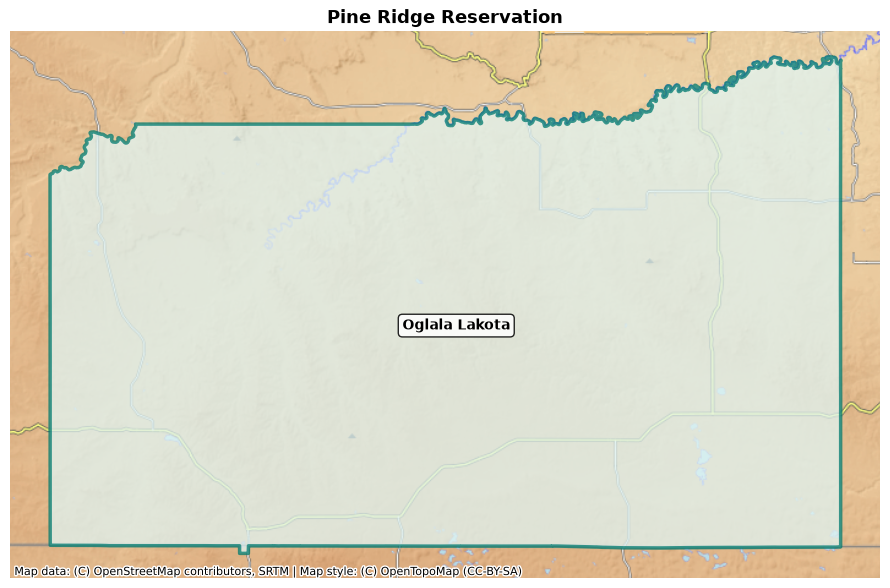

Saved: figures/01_study_area.png


In [4]:
# Pine Ridge Reservation overview map
fig, ax = plt.subplots(figsize=(9, 7))
primary.to_crs(CRS_WEB).plot(
    ax=ax, facecolor=TEAL_LT, edgecolor=TEAL, linewidth=2.5, alpha=0.75
)
for _, row in primary.iterrows():
    center = gpd.GeoSeries([row.geometry.centroid], crs=CRS_GEOGRAPHIC).to_crs(CRS_WEB).iloc[0]
    ax.annotate(
        row["common_name"], (center.x, center.y), ha="center", fontsize=10,
        fontweight="bold", bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.85)
    )
try:
    ctx.add_basemap(ax, source=ctx.providers.OpenTopoMap, alpha=0.7, zoom=9)
except Exception:
    pass
ax.set_axis_off()
ax.set_title("Pine Ridge Reservation", fontsize=13, fontweight="bold")
plt.tight_layout()
fig.savefig(FIGURES_DIR/"01_study_area.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: figures/01_study_area.png")

## Physiographic and Structural Setting

Western South Dakota lies within the northern Great Plains physiographic
province. The study area spans the transition between three structural domains:

**The Black Hills Uplift** is a domal anticline exposing Precambrian rocks at
its core. The regional eastward dip off this uplift controls the depth and
geometry of every formation across Pine Ridge.

**The Missouri Plateau** is the high plains surface, primarily underlain by
the Pierre Shale and capped by Cretaceous and Paleogene units. Most of Pine
Ridge and Pine Ridge occupies this terrain.

**The White River Badlands** are the deeply dissected eastern escarpment where
the White River Group (Oligocene) overlies the Pierre Shale. The Badlands
form the northeastern boundary of Pine Ridge. Their striking topography is
the erosional expression of the stratigraphic boundary between these two units.

In [5]:
# Stream network shows drainage architecture controlled by geology
print("Loading drainage network...")
streams_pr = load_nhd_flowlines(PINE_RIDGE_BBOX, min_stream_order=2)

if not streams_pr.empty:
    print(f"Pine Ridge streams (order ≥ 2): {len(streams_pr)}")

Loading drainage network...
  Fetched 2000 features (offset 0)
  Fetched 2000 features (offset 2000)
  Fetched 2000 features (offset 4000)
  Fetched 2000 features (offset 6000)
  Fetched 2000 features (offset 8000)
  Fetched 2000 features (offset 10000)
  Fetched 2000 features (offset 12000)
  Fetched 2000 features (offset 14000)
  Fetched 2000 features (offset 16000)
  Fetched 2000 features (offset 18000)
  Fetched 2000 features (offset 20000)
  Fetched 2000 features (offset 0)
  Fetched 2000 features (offset 2000)
  Fetched 2000 features (offset 4000)
  Fetched 2000 features (offset 6000)
  Fetched 2000 features (offset 8000)
  Fetched 2000 features (offset 10000)
  Fetched 2000 features (offset 12000)
  Fetched 2000 features (offset 14000)
  Fetched 2000 features (offset 16000)
  Fetched 2000 features (offset 18000)
  Fetched 2000 features (offset 20000)
  Fetched 1186 features (offset 22000)
Total stream segments: 23,186
Pine Ridge streams (order ≥ 2): 23186


## Regional Stratigraphic Column

The following stratigraphic units are present across the study area, from
youngest (surface) to oldest (deepest). This column is derived from the
Spangler (2024) 3D model 25 units modeled from surface to Precambrian
basement.

Units marked with + are of particular significance for land and water
management on Pine Ridge.

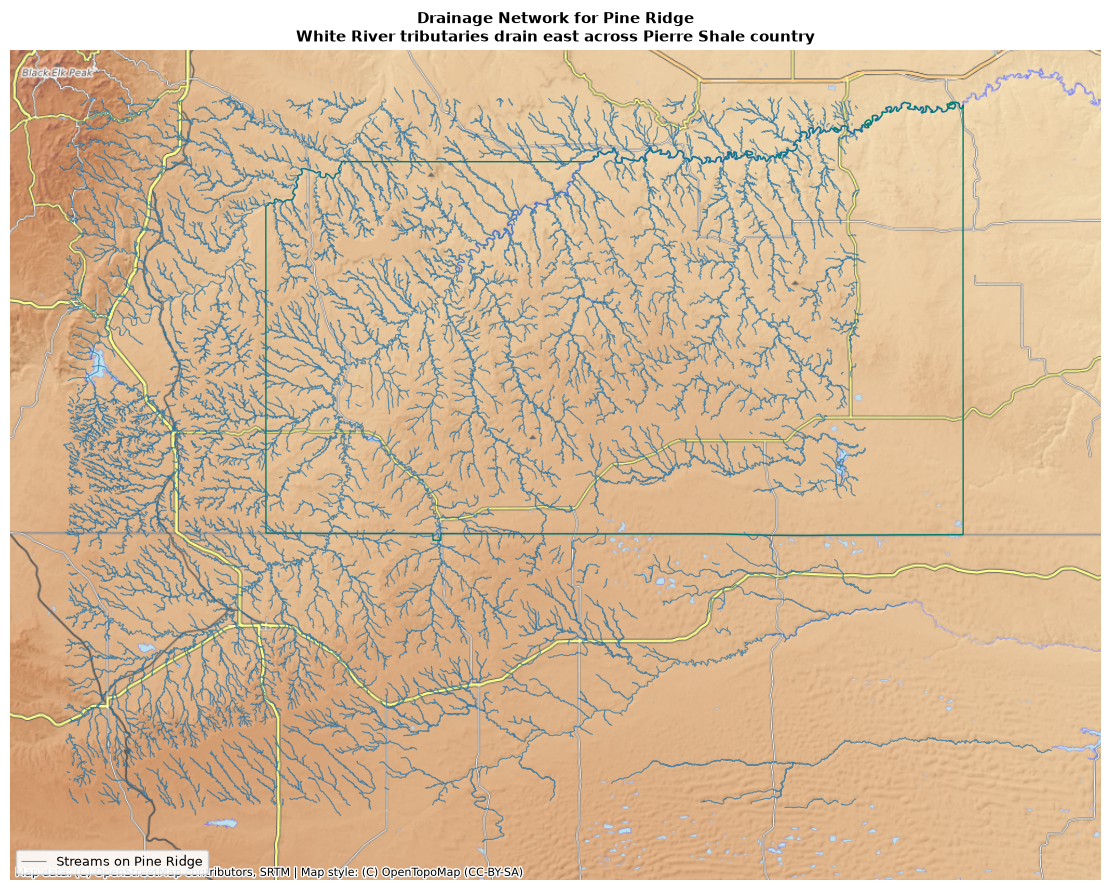

In [6]:
# Hydrologic context map
fig, ax = plt.subplots(figsize=(13, 9))

primary_boundary = primary.dissolve()
primary_boundary.to_crs(CRS_WEB).plot(ax=ax, facecolor="none", edgecolor=TEAL,
                                       linewidth=1.0, zorder=3)

if not streams_pr.empty:
    streams_pr.to_crs(CRS_WEB).plot(ax=ax, color="#2471A3", linewidth=0.8,
                                     alpha=0.7, zorder=4, label="Streams on Pine Ridge")

try:
    ctx.add_basemap(ax, source=ctx.providers.OpenTopoMap, alpha=0.65, zoom=9)
except Exception:
    pass

ax.set_axis_off()
ax.legend(fontsize=9, loc="lower left", framealpha=0.9)
ax.set_title(
    "Drainage Network for Pine Ridge\n"
    "White River tributaries drain east across Pierre Shale country",
    fontsize=11, fontweight="bold"
)
plt.tight_layout()
fig.savefig(FIGURES_DIR/"01_drainage_network.png", dpi=150, bbox_inches="tight")
plt.show()

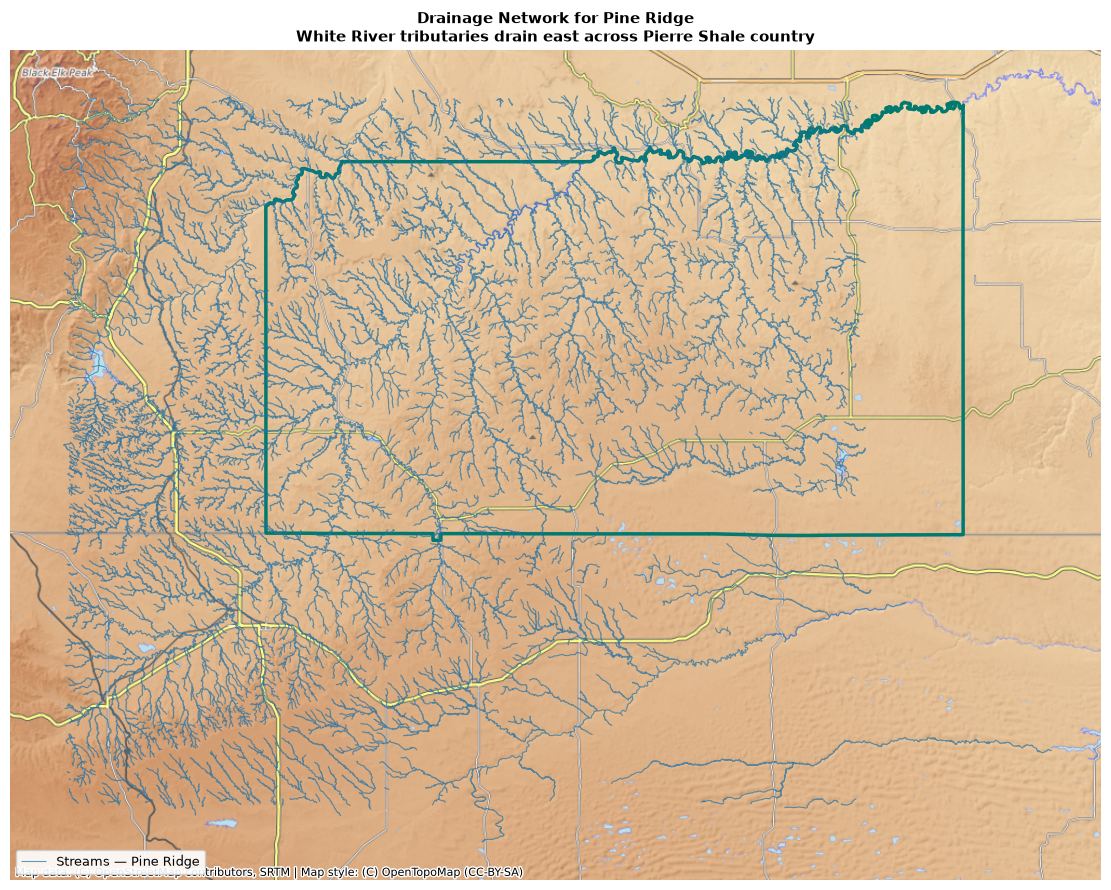

In [7]:
pine_ridge_boundary = load_tribal_boundaries(["Pine Ridge"])
fig, ax = plt.subplots(figsize=(13, 9))

pine_ridge_boundary.to_crs(CRS_WEB).plot(ax=ax, facecolor="none", edgecolor=TEAL,
                                          linewidth=2.5, zorder=3)

if not streams_pr.empty:
    streams_pr.to_crs(CRS_WEB).plot(ax=ax, color="#2471A3", linewidth=0.8,
                                     alpha=0.7, zorder=4, label="Streams — Pine Ridge")

try:
    ctx.add_basemap(ax, source=ctx.providers.OpenTopoMap, alpha=0.65, zoom=9)
except Exception:
    pass

ax.set_axis_off()
ax.legend(fontsize=9, loc="lower left", framealpha=0.9)
ax.set_title(
    "Drainage Network for Pine Ridge\n"
    "White River tributaries drain east across Pierre Shale country",
    fontsize=11, fontweight="bold"
)
plt.tight_layout()
fig.savefig(FIGURES_DIR/"01_drainage_network.png", dpi=150, bbox_inches="tight")
plt.show()

23186
  Fetched 2000 features (offset 0)
  Fetched 2000 features (offset 2000)
  Fetched 2000 features (offset 4000)
  Fetched 180 features (offset 6000)
Total stream segments: 6,180
Named streams only: 6,180 segments
Named streams present:
gnis_name
White River                308
Rush Creek                 210
Dry Creek                  205
Bear-in-the-Lodge Creek    148
Horsehead Creek            145
Cottonwood Creek           140
Cheyenne River             124
Spring Creek               115
White Clay Creek           115
Wounded Knee Creek         111
Little White River          99
Antelope Creek              92
Porcupine Creek             88
Hay Springs Creek           88
Niobrara River              86
French Creek                84
Craven Creek                77
Beaver Creek                75
Slim Butte Creek            71
Corn Creek                  67


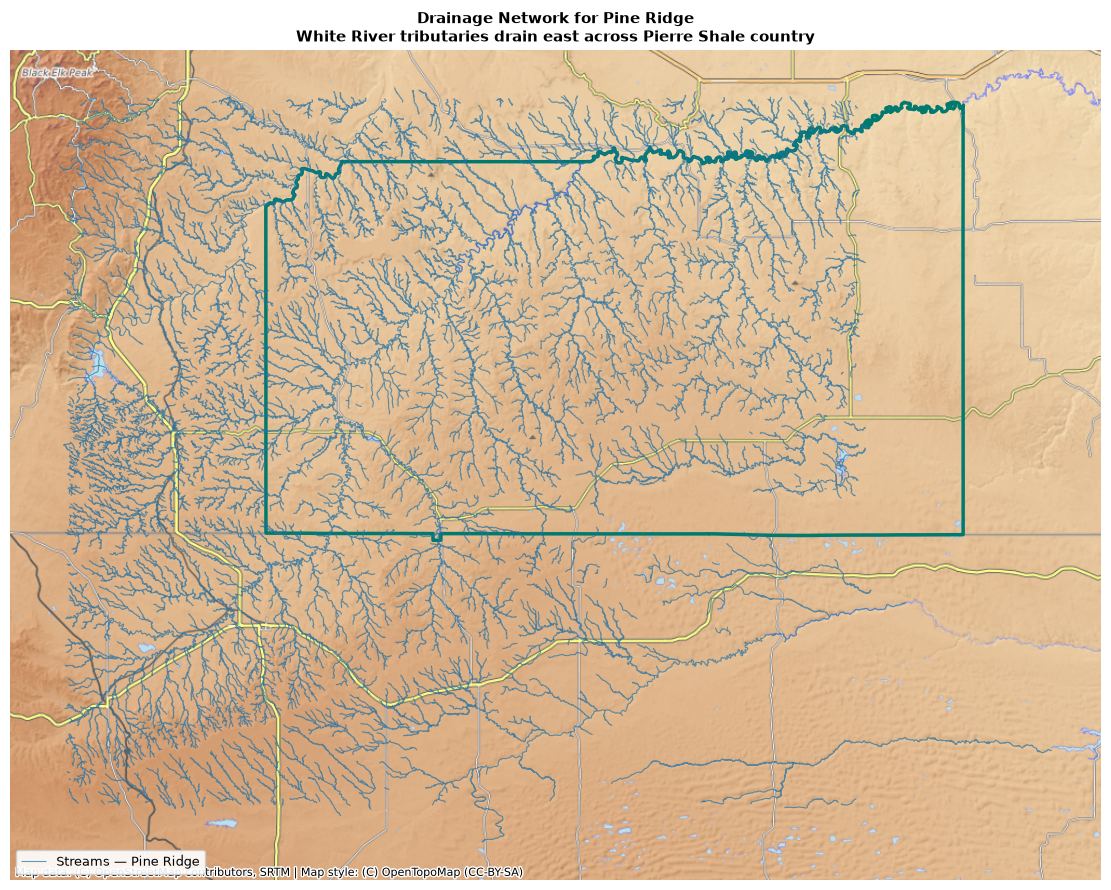

In [8]:
# streams_pr = load_nhd_flowlines(PINE_RIDGE_BBOX, min_stream_order=2, force_refresh=True)
print(len(streams_pr))
streams_named = load_nhd_flowlines(PINE_RIDGE_BBOX, named_only=True)
print(f"Named streams only: {len(streams_named):,} segments")
print("Named streams present:")
print(streams_named["gnis_name"].value_counts().head(20).to_string())

pine_ridge_boundary = load_tribal_boundaries(["Pine Ridge"])
fig, ax = plt.subplots(figsize=(13, 9))

pine_ridge_boundary.to_crs(CRS_WEB).plot(ax=ax, facecolor="none", edgecolor=TEAL,
                                          linewidth=2.5, zorder=3)

if not streams_pr.empty:
    streams_pr.to_crs(CRS_WEB).plot(ax=ax, color="#2471A3", linewidth=0.8,
                                     alpha=0.7, zorder=4, label="Streams — Pine Ridge")

try:
    ctx.add_basemap(ax, source=ctx.providers.OpenTopoMap, alpha=0.65, zoom=9)
except Exception:
    pass

ax.set_axis_off()
ax.legend(fontsize=9, loc="lower left", framealpha=0.9)
ax.set_title(
    "Drainage Network for Pine Ridge\n"
    "White River tributaries drain east across Pierre Shale country",
    fontsize=11, fontweight="bold"
)
plt.tight_layout()
fig.savefig(FIGURES_DIR/"01_drainage_network.png", dpi=150, bbox_inches="tight")
plt.show()

In [9]:
# Print the stratigraphic column with management significance flags
print("REGIONAL STRATIGRAPHIC COLUMN for Western South Dakota")
print("Pine Ridge study area | Spangler (2024)")
print(f"{'Unit':<35} {'Significance'}")

for unit in WSD_STRATIGRAPHY:
    note = WSD_KEY_UNITS.get(unit, "")
    star = "+ " if note else "  "
    print(f"  {star}{unit:<33} {note[:50] if note else ''}")

print()
print("+ = significant for land and water management")
print()
print("Source: Spangler, L.R., 2024.")
print(f"DOI: {WSD_3D_MODEL['doi']}")
print(f"License: {WSD_3D_MODEL['license']}")

REGIONAL STRATIGRAPHIC COLUMN for Western South Dakota
Pine Ridge study area | Spangler (2024)
Unit                                Significance
    Glacial sediments                 
    Ogallala Group                    
  + Hell Creek Formation              Near-surface on eastern portion paleontological re
    Lance Formation                   
    Fox Hills Formation               
  + Pierre Shale                      Expansive clay controls slope instability, swellin
  + Niobrara Formation                Fractured chalk secondary aquifer in some areas
    Carlile Shale                     
    Greenhorn Formation               
    Mowry Shale                       
    Belle Fourche Shale               
    Morrison Formation                
    Sundance Formation                
    Inyan Kara Group                  
    Minnelusa Formation               
    Minnekahta Formation              
    Spearfish Formation               
    Three Forks Shale                 
  + Mad

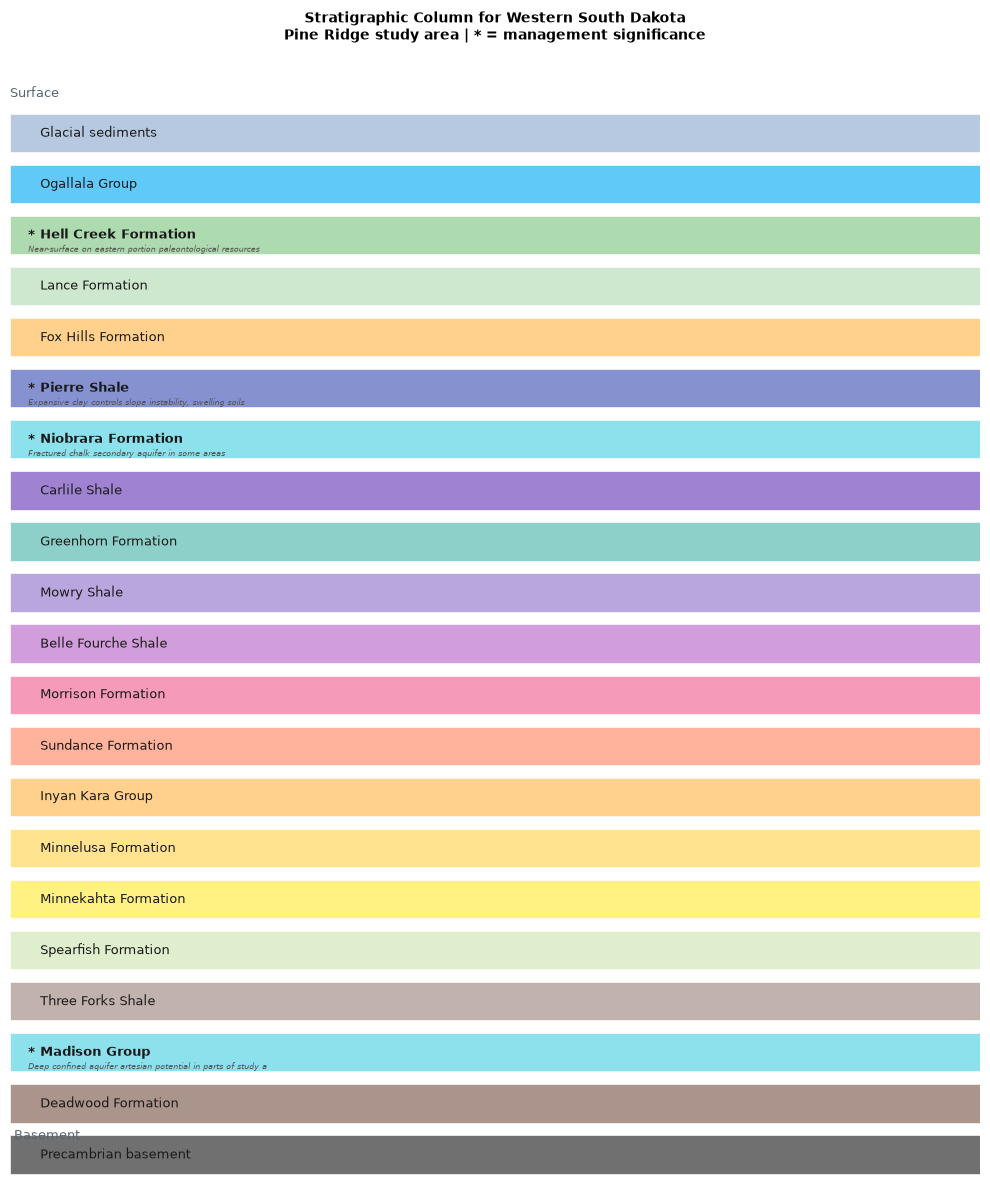

Saved: figures/01_stratigraphic_column.png


In [10]:
# Visualize stratigraphic column as a graphic
fig, ax = plt.subplots(figsize=(10, 12))

# Color scheme by era/significance
unit_colors = {
    "Glacial sediments":      "#B0C4DE",
    "Ogallala Group":         "#4FC3F7",   # water blue
    "Hell Creek Formation":   "#A5D6A7",
    "Lance Formation":        "#C8E6C9",
    "Fox Hills Formation":    "#FFCC80",
    "Pierre Shale":           "#7986CB",   # distinctive purple
    "Niobrara Formation":     "#80DEEA",
    "Carlile Shale":          "#9575CD",
    "Greenhorn Formation":    "#80CBC4",
    "Mowry Shale":            "#B39DDB",
    "Belle Fourche Shale":    "#CE93D8",
    "Morrison Formation":     "#F48FB1",
    "Sundance Formation":     "#FFAB91",
    "Inyan Kara Group":       "#FFCC80",
    "Minnelusa Formation":    "#FFE082",
    "Minnekahta Formation":   "#FFF176",
    "Spearfish Formation":    "#DCEDC8",
    "Three Forks Shale":      "#BCAAA4",
    "Madison Group":          "#80DEEA",   # water blue
    "Deadwood Formation":     "#A1887F",
    "Precambrian basement":   "#616161",
}

n = len(WSD_STRATIGRAPHY)
bar_height = 0.75

for i, unit in enumerate(WSD_STRATIGRAPHY):
    y = n - i - 1
    color = unit_colors.get(unit, "#E0E0E0")
    ax.barh(y, 8, left=0, height=bar_height, color=color, alpha=0.9,
            edgecolor="white", linewidth=0.5)
    note = WSD_KEY_UNITS.get(unit, "")
    star = "* " if note else "   "
    label = f"{star}{unit}"
    ax.text(0.15, y, label, va="center", ha="left", fontsize=9, fontweight="bold"
            if note else "normal", color="#1a1a1a")
    if note:
        ax.text(0.15, y - 0.28, note[:60], va="center", ha="left",
                fontsize=6, color="#555555", style="italic")

ax.set_xlim(0, 8)
ax.set_ylim(-0.5, n + 0.5)
ax.set_yticks([])
ax.set_xticks([])
ax.set_xlabel("")
for spine in ax.spines.values():
    spine.set_visible(False)

ax.annotate("Surface ", xy=(0, n - 0.3), fontsize=9, color=GRAY,
            ha="left")
ax.annotate(" Basement", xy=(0, 0.3), fontsize=9, color=GRAY,
            ha="left")

ax.set_title(
    "Stratigraphic Column for Western South Dakota\n"
    "Pine Ridge study area | * = management significance",
    fontsize=10, fontweight="bold", pad=12
)
plt.tight_layout()
fig.savefig(FIGURES_DIR/"01_stratigraphic_column.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: figures/01_stratigraphic_column.png")

## Summary

This notebook established the spatial and stratigraphic framework for the
series. Key takeaways for the notebooks that follow:

- Pine Ridge occupy the eastern flank of the Black Hills uplift
  and the Missouri Plateau structurally simple, but with regionally
  significant stratigraphy
- The Pierre Shale is the dominant near-surface formation across most of both
  reservations its expansive clay mineralogy (smectite) controls slope
  stability, soil behavior, and road engineering conditions (notebook 07)
- The Ogallala Group (Arikaree aquifer) is the primary water supply for both
  reservations its thickness and depth vary systematically across the study
  area (notebook 08)
- The 3D model (Spangler 2024) provides the subsurface horizon data that
  makes quantitative analysis of depth-to-formation possible for the first
  time in a Tribal land context (notebook 04)
- Stream drainage follows the regional dip and the White River system the
  surface hydrology reflects the same structural control as the stratigraphy

**Next:** Notebook 02 covers surficial geology the Quaternary deposits that
directly underlie the soils and control near-surface engineering behavior.

In [11]:
# Print citations
print(generate_citations(["usgs_3d_model", "census_aiannh"]))

DATA CITATIONS

USGS 3D Geological Model of Western South Dakota
  Spangler, L.R., 2024, Digital data for a 3D Geological Model of western South Dakota, USA: U.S. Geological Survey data release, https://doi.org/10.5066/P9LK4QHJ.
  https://doi.org/10.5066/P9LK4QHJ
  Steward: US Geological Survey, Rocky Mountain Region | License: CC0 1.0 Universal (Public Domain)

US Census Bureau TIGER/Line AIANNH Boundaries
  US Census Bureau. TIGER/Line Shapefiles: American Indian / Alaska Native / Native Hawaiian Areas (AIANNH). https://www.census.gov/geographies/mapping-files/time-series/geo/tiger-line-file.html
  https://www.census.gov/geographies/mapping-files/
  Steward: US Census Bureau | License: Public domain

TERRITORIAL PROVENANCE
  1868 Fort Laramie Treaty territory relevant to the Oglala Sioux Tribe, including the Great Sioux Reservation
  Pine Ridge Reservation is the sovereign territory of the Oglala Sioux Tribe and the homeland of the Oglala Lakota people. Federal and state geological s